# Notebook — Merge Separately-Run Experiment Results

**Purpose:** Reload each saved `.pkl` model file, reconstruct `TrainingResult` objects,
merge them into a single `ResultsTracker`, and generate the complete
summary table, figures, and report.

**Run this after:** All four experiments and the sensitivity analysis have completed
separately and their `.pkl` files exist in `outputs/models/`.

**What this notebook does:**
1. Scan `outputs/models/` to find all saved experiment files
2. Load each file and reconstruct a `TrainingResult` from its stored data
3. Re-evaluate on test set using saved thresholds (no re-training)
4. Log all results into `ResultsTracker`
5. Generate comparison table, figures, and plain-text report
6. Save `results.csv`, `comparison_table.csv`, `sensitivity_results.csv`

In [9]:
import os, sys, pickle, glob
import numpy as np
import pandas as pd
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=False)


# ── Path setup ────────────────────────────────────────────────────────────────
# Adjust project_root to match your Google Drive path
project_root = '/content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX'
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.cost_matrix      import CostMatrix, ThresholdOptimiser
from src.model            import TrainingResult, LogLoss, FocalLoss, CostAwareFocalLoss
from src.results_tracker  import ResultsTracker, FigureGenerator, ReportGenerator

# ── Directory paths ───────────────────────────────────────────────────────────
MODELS_DIR    = os.path.join(project_root, 'outputs', 'models')
RESULTS_DIR   = os.path.join(project_root, 'outputs', 'results')
FIGURES_DIR   = os.path.join(project_root, 'outputs', 'figures')
PROCESSED_DIR = os.path.join(project_root, 'data', 'processed')
DATA_DIR      = os.path.join(project_root, 'data', 'raw')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

print('Setup OK')
print(f'Models dir : {MODELS_DIR}')
print(f'Results dir: {RESULTS_DIR}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup OK
Models dir : /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/models
Results dir: /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/results


In [10]:
# ── Step 1: Scan all saved model files ───────────────────────────────────────
# Lists every .pkl file in outputs/models/ so you can confirm what was saved

pkl_files = sorted(glob.glob(os.path.join(MODELS_DIR, '*.pkl')))

print(f'Found {len(pkl_files)} .pkl files in {MODELS_DIR}:')
for f in pkl_files:
    size_kb = os.path.getsize(f) / 1024
    print(f'  {os.path.basename(f):<50}  {size_kb:6.1f} KB')

if not pkl_files:
    print('\nWARNING: No .pkl files found.')
    print('Check that MODELS_DIR path is correct and experiments have completed.')

Found 12 .pkl files in /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/models:
  exp1_log_loss.pkl                                     61.0 KB
  exp2_focal_loss.pkl                                 1869.4 KB
  exp3_cost_aware_focal_fn1_0.pkl                       45.1 KB
  exp3_sensitivity_fn0_25_fn0_25.pkl                    14.3 KB
  exp3_sensitivity_fn0_5_fn0_5.pkl                     223.7 KB
  exp3_sensitivity_fn0_75_fn0_75.pkl                   411.4 KB
  exp3_sensitivity_fn1_0_fn1_0.pkl                     128.8 KB
  exp3_sensitivity_fn1_5_fn1_5.pkl                      69.3 KB
  exp3_sensitivity_fn2_0_fn2_0.pkl                      69.2 KB
  exp3_sensitivity_fn3_0_fn3_0.pkl                      64.5 KB
  exp4_cost_aware_fn05.pkl                             223.8 KB
  pipeline_state.pkl                                     7.2 KB


In [11]:
# ── Step 2: Load processed data (needed for test-set re-evaluation) ───────────
# These parquet files were saved by run_experiments.py --pipeline-only

X_val  = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_val.parquet'))
y_val  = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_val.parquet')).squeeze()
X_test = pd.read_parquet(os.path.join(PROCESSED_DIR, 'X_test.parquet'))
y_test = pd.read_parquet(os.path.join(PROCESSED_DIR, 'y_test.parquet')).squeeze()

# Load 5-class temporal labels for cost evaluation
val_labels  = pd.read_csv(os.path.join(DATA_DIR, 'validation_labels.csv'))
test_labels = pd.read_csv(os.path.join(DATA_DIR, 'test_labels.csv'))
y_val_5class  = val_labels['class_label'].values.astype(int)
y_test_5class = test_labels['class_label'].values.astype(int)
y_val_binary  = y_val.values.astype(int)
y_test_binary = y_test.values.astype(int)

# Align categorical dtypes between val and test
cat_cols = X_val.select_dtypes('category').columns.tolist()
X_test_aligned = X_test.copy()
for col in cat_cols:
    if col in X_test_aligned.columns:
        X_test_aligned[col] = X_test_aligned[col].astype(X_val[col].dtype)

print(f'X_val  : {X_val.shape}')
print(f'X_test : {X_test.shape}')
print(f'Val  5-class dist: {dict(zip(*np.unique(y_val_5class,  return_counts=True)))}')
print(f'Test 5-class dist: {dict(zip(*np.unique(y_test_5class, return_counts=True)))}')

X_val  : (5046, 183)
X_test : (5045, 183)
Val  5-class dist: {np.int64(0): np.int64(4910), np.int64(1): np.int64(16), np.int64(2): np.int64(14), np.int64(3): np.int64(30), np.int64(4): np.int64(76)}
Test 5-class dist: {np.int64(0): np.int64(4903), np.int64(1): np.int64(26), np.int64(2): np.int64(15), np.int64(3): np.int64(41), np.int64(4): np.int64(60)}


In [12]:
# ── Step 3: Reconstruction helper ────────────────────────────────────────────

def reconstruct_result(
    pkl_path:     str,
    X_val:        pd.DataFrame,
    y_val_binary: np.ndarray,
    y_val_5class: np.ndarray,
    X_test:       pd.DataFrame,
    y_test_binary:np.ndarray,
    y_test_5class:np.ndarray,
    fn_weight:    float = 1.0,
) -> 'TrainingResult':
    from sklearn.metrics import (
        roc_auc_score, precision_score, recall_score,
        f1_score, average_precision_score
    )

    with open(pkl_path, 'rb') as f:
        state = pickle.load(f)

    booster      = lgb.Booster(model_str=state['booster_str'])
    loss_name    = state['loss_name']
    loss_params  = state.get('loss_params', {})
    cm           = CostMatrix(fn_weight=fn_weight)

    if loss_name == 'log_loss':
        loss_fn = LogLoss()
    elif loss_name == 'focal_loss':
        loss_fn = FocalLoss(gamma=loss_params.get('gamma', 2.0))
    elif loss_name == 'cost_aware_focal_loss':
        loss_fn = CostAwareFocalLoss(
            cost_matrix=cm, gamma=loss_params.get('gamma', 2.0), fn_weight=fn_weight
        )
    else:
        raise ValueError(f'Unknown loss_name: {loss_name}')

    thresholds = state.get('thresholds')
    if thresholds is None:
        thresholds = state.get('optimiser_state', {}).get('best_thresholds')

    def sigmoid(x): return 1 / (1 + np.exp(-x))
    raw_val  = booster.predict(X_val)
    raw_test = booster.predict(X_test)
    if raw_val.min() < -1 or raw_val.max() > 1:
        val_probs  = sigmoid(raw_val)
        test_probs = sigmoid(raw_test)
    else:
        val_probs, test_probs = raw_val, raw_test

    def probs_to_class(probs, thresholds):
        t1, t2, t3, t4 = thresholds
        y_pred = np.zeros(len(probs), dtype=int)
        y_pred[probs >= t1] = 1
        y_pred[probs >= t2] = 2
        y_pred[probs >= t3] = 3
        y_pred[probs >= t4] = 4
        return y_pred

    val_pred  = probs_to_class(val_probs,  thresholds)
    test_pred = probs_to_class(test_probs, thresholds)

    val_cost  = cm.total_cost(y_val_5class,  val_pred)
    test_cost = cm.total_cost(y_test_5class, test_pred)

    val_auc   = roc_auc_score(y_val_binary,  val_probs)
    test_auc  = roc_auc_score(y_test_binary, test_probs)

    # Binary predictions at t1 — the failure/healthy boundary
    t1 = thresholds[0]
    test_bin_pred  = (test_probs >= t1).astype(int)
    test_precision = precision_score(y_test_binary, test_bin_pred, zero_division=0)
    test_recall    = recall_score(   y_test_binary, test_bin_pred, zero_division=0)
    test_f1        = f1_score(       y_test_binary, test_bin_pred, zero_division=0)
    test_pr_auc    = average_precision_score(y_test_binary, test_probs)

    stored_summary   = state.get('summary', {})
    stored_val_cost  = stored_summary.get('val_total_cost')
    if stored_val_cost is not None and abs(val_cost - stored_val_cost) > 10:
        print(f'  WARNING {os.path.basename(pkl_path)}: '
              f'recomputed val_cost={val_cost:.0f} vs stored={stored_val_cost:.0f} '
              f'— check label alignment')

    result = TrainingResult(
        experiment_name = stored_summary.get('experiment_name',
                          os.path.basename(pkl_path).replace('.pkl', '')),
        loss_name       = loss_name,
        loss_params     = loss_fn.params,
        model           = booster,
        thresholds      = tuple(thresholds) if thresholds is not None else None,
        best_iteration  = stored_summary.get('best_iteration'),
        train_logloss   = stored_summary.get('train_logloss'),
        val_logloss     = stored_summary.get('val_logloss'),
        val_total_cost  = val_cost,
        test_total_cost = test_cost,
        val_probs       = val_probs,
        test_probs      = test_probs,
        val_roc_auc     = val_auc,
        test_roc_auc    = test_auc,
        test_precision  = test_precision,
        test_recall     = test_recall,
        test_f1         = test_f1,
        test_pr_auc     = test_pr_auc,
    )

    print(f'  Loaded  {os.path.basename(pkl_path):<45}'
          f'  val_cost={val_cost:>8.0f}  test_cost={test_cost:>8.0f}'
          f'  test_auc={test_auc:.4f}  P={test_precision:.3f}'
          f'  R={test_recall:.3f}  F1={test_f1:.3f}')
    return result

In [13]:
# ── Step 4: Load all four main experiments ────────────────────────────────────
#
# Edit the file names below if your saved files have different names.
# The names shown here match what run_experiments.py saves by default.
#
# fn_weight mapping:
#   Exp1, Exp2, Exp3  →  fn_weight=1.0  (original cost matrix)
#   Exp4              →  fn_weight=0.5  (scaled cost matrix)

EXPERIMENT_MAP = [
    # (pkl_filename,                       fn_weight, description)
    ('exp1_log_loss.pkl',                  1.0,  'Exp1 — Log-loss baseline'),
    ('exp2_focal_loss.pkl',                1.0,  'Exp2 — Focal loss'),
    ('exp3_cost_aware_focal_fn1_0.pkl',    1.0,  'Exp3 — Cost-aware focal (fn_weight=1.0)'),
    ('exp4_cost_aware_fn05.pkl',           0.5,  'Exp4 — Cost-aware focal (fn_weight=0.5)'),
]

# If your filenames differ, update the list above.
# The cell below will warn you about any missing files.

print('Verifying experiment files exist...')
for fname, fw, desc in EXPERIMENT_MAP:
    full_path = os.path.join(MODELS_DIR, fname)
    exists = os.path.exists(full_path)
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status}]  {desc:<45}  {fname}')

Verifying experiment files exist...
  [OK]  Exp1 — Log-loss baseline                       exp1_log_loss.pkl
  [OK]  Exp2 — Focal loss                              exp2_focal_loss.pkl
  [OK]  Exp3 — Cost-aware focal (fn_weight=1.0)        exp3_cost_aware_focal_fn1_0.pkl
  [OK]  Exp4 — Cost-aware focal (fn_weight=0.5)        exp4_cost_aware_fn05.pkl


In [14]:
# ── Step 5: Reconstruct all TrainingResult objects ────────────────────────────

print('Reconstructing results...\n')
results = {}

for fname, fn_weight, desc in EXPERIMENT_MAP:
    full_path = os.path.join(MODELS_DIR, fname)
    if not os.path.exists(full_path):
        print(f'  SKIP (file not found): {fname}')
        continue
    try:
        key = fname.replace('.pkl', '')
        results[key] = reconstruct_result(
            pkl_path      = full_path,
            X_val         = X_val,
            y_val_binary  = y_val_binary,
            y_val_5class  = y_val_5class,
            X_test        = X_test_aligned,
            y_test_binary = y_test_binary,
            y_test_5class = y_test_5class,
            fn_weight     = fn_weight,
        )
    except Exception as e:
        print(f'  ERROR loading {fname}: {e}')

print(f'\nSuccessfully loaded {len(results)} experiment(s).')

Reconstructing results...

  Loaded  exp1_log_loss.pkl                              val_cost=   43472  test_cost=   46393  test_auc=0.6340  P=0.038  R=0.796  F1=0.072
  Loaded  exp2_focal_loss.pkl                            val_cost=   43987  test_cost=   46345  test_auc=0.6327  P=0.039  R=0.810  F1=0.075
  WARNING exp3_cost_aware_focal_fn1_0.pkl: recomputed val_cost=70263 vs stored=48916 — check label alignment
  Loaded  exp3_cost_aware_focal_fn1_0.pkl                val_cost=   70263  test_cost=   68115  test_auc=0.6647  P=0.032  R=0.930  F1=0.063
  Loaded  exp4_cost_aware_fn05.pkl                       val_cost=   28700  test_cost=   28050  test_auc=0.5000  P=0.000  R=0.000  F1=0.000

Successfully loaded 4 experiment(s).


In [15]:
# ── Step 6: Load sensitivity analysis results ─────────────────────────────────

print('Loading sensitivity analysis results...\n')

sens_files = sorted(glob.glob(os.path.join(MODELS_DIR, 'exp3_sensitivity_fn*.pkl')))
if not sens_files:
    sens_files = sorted(glob.glob(os.path.join(MODELS_DIR, '*fn_weight*.pkl')))

sensitivity_rows = []

for pkl_path in sens_files:
    fname = os.path.basename(pkl_path)
    try:
        # Handles: fn0_5.pkl → '0_5' → 0.5
        #          fn0_25.pkl → '0_25' → 0.25
        #          fn1_0.pkl  → '1_0'  → 1.0
        fn_part   = fname.split('fn')[-1].replace('.pkl', '')
        parts     = fn_part.split('_')          # ['0','5'] or ['0','25'] or ['1','0']
        fn_weight = float(parts[0]) + float(parts[1]) / (10 ** len(parts[1]))
    except Exception:
        print(f'  Could not parse fn_weight from {fname} — skipping')
        continue

    try:
        r = reconstruct_result(
            pkl_path=pkl_path, X_val=X_val,
            y_val_binary=y_val_binary, y_val_5class=y_val_5class,
            X_test=X_test_aligned,
            y_test_binary=y_test_binary, y_test_5class=y_test_5class,
            fn_weight=fn_weight,
        )
        sensitivity_rows.append({
            'fn_weight':       fn_weight,
            'alpha':           r.loss_params.get('alpha'),
            'best_gamma':      r.loss_params.get('gamma'),
            'val_total_cost':  r.val_total_cost,
            'test_total_cost': r.test_total_cost,
            'val_roc_auc':     r.val_roc_auc,
            'test_roc_auc':    r.test_roc_auc,
            'threshold_t1':    r.thresholds[0] if r.thresholds else None,
            'threshold_t2':    r.thresholds[1] if r.thresholds else None,
            'threshold_t3':    r.thresholds[2] if r.thresholds else None,
            'threshold_t4':    r.thresholds[3] if r.thresholds else None,
        })
    except Exception as e:
        print(f'  ERROR loading {fname}: {e}')

if sensitivity_rows:
    sensitivity_df = pd.DataFrame(sensitivity_rows).sort_values('fn_weight').reset_index(drop=True)
    print(f'\nSensitivity results: {len(sensitivity_df)} fn_weight values loaded')
    print(sensitivity_df[['fn_weight','alpha','val_total_cost','test_total_cost']].to_string(index=False))
else:
    csv_path = os.path.join(RESULTS_DIR, 'sensitivity_results.csv')
    if os.path.exists(csv_path):
        sensitivity_df = pd.read_csv(csv_path)
        print(f'Loaded sensitivity CSV ← {csv_path}')
        print(sensitivity_df[['fn_weight','alpha','val_total_cost','test_total_cost']].to_string(index=False))
    else:
        sensitivity_df = None
        print('No sensitivity pkl or CSV found.')

Loading sensitivity analysis results...

  Loaded  exp3_sensitivity_fn0_25_fn0_25.pkl             val_cost=   14350  test_cost=   14025  test_auc=0.3725  P=0.000  R=0.000  F1=0.000
  Loaded  exp3_sensitivity_fn0_5_fn0_5.pkl               val_cost=   28700  test_cost=   28050  test_auc=0.5000  P=0.000  R=0.000  F1=0.000
  Loaded  exp3_sensitivity_fn0_75_fn0_75.pkl             val_cost=   43050  test_cost=   42075  test_auc=0.5000  P=0.000  R=0.000  F1=0.000
  WARNING exp3_sensitivity_fn1_0_fn1_0.pkl: recomputed val_cost=71626 vs stored=48892 — check label alignment
  Loaded  exp3_sensitivity_fn1_0_fn1_0.pkl               val_cost=   71626  test_cost=   69159  test_auc=0.7103  P=0.032  R=0.986  F1=0.062
  WARNING exp3_sensitivity_fn1_5_fn1_5.pkl: recomputed val_cost=66026 vs stored=49278 — check label alignment
  Loaded  exp3_sensitivity_fn1_5_fn1_5.pkl               val_cost=   66026  test_cost=   61513  test_auc=0.6707  P=0.032  R=0.958  F1=0.063
  WARNING exp3_sensitivity_fn2_0_fn2_0.

In [16]:
# ── Step 7: Build the unified ResultsTracker ──────────────────────────────────
#
# Log all experiments in the correct order for the comparison table.
# Order matters: Exp1 is the baseline — it must be logged first so the
# cost_reduction_pct column is computed relative to Exp1.

tracker = ResultsTracker(output_dir=RESULTS_DIR)

LOG_ORDER = [
    'exp1_log_loss',
    'exp2_focal_loss',
    'exp3_cost_aware_focal_loss',
    'exp4_cost_aware_fn05',
]

print('Logging experiments into ResultsTracker...\n')
for key in LOG_ORDER:
    if key in results:
        tracker.log(results[key], split='test')
    else:
        print(f'  SKIP (not loaded): {key}')

# Log sensitivity results
if sensitivity_df is not None:
    tracker.log_sensitivity(sensitivity_df)

# Save all results to CSV
tracker.save_all_results()
print('\nResults CSV saved.')

Logging experiments into ResultsTracker...

  [Tracker] logged: exp1_log_loss  test_cost=46393.0  test_auc=0.6340103644506238
  [Tracker] logged: exp2_focal_loss  test_cost=46345.0  test_auc=0.6326997268128453
  SKIP (not loaded): exp3_cost_aware_focal_loss
  [Tracker] logged: exp4_cost_aware_fn05  test_cost=28050.0  test_auc=0.5
  [Tracker] sensitivity results saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/results/sensitivity_results.csv
  [Tracker] results saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/results/results.csv  (3 rows)

Results CSV saved.


In [17]:
# ── Step 8: Print the master comparison table ─────────────────────────────────

tracker.print_summary()

comparison = tracker.comparison_table()
print('\n── Full comparison table ──')
print(comparison.to_string(index=False))

# Save comparison table
comp_path = os.path.join(RESULTS_DIR, 'comparison_table.csv')
comparison.to_csv(comp_path, index=False)
print(f'\nComparison table saved → {comp_path}')


  RESULTS SUMMARY
  Experiment                            Val cost   Test cost      AUC
  ─────────────────────────────────────────────────────────────────
  exp1_log_loss                         43472.00    46393.00   0.6340
  exp2_focal_loss                       43987.00    46345.00   0.6327
  exp4_cost_aware_fn05                  28700.00    28050.00   0.5000

  Cost change (first → last) : +18343.00  (+39.5%)

── Full comparison table ──
     experiment_name             loss_name  val_total_cost  test_total_cost  val_roc_auc  test_roc_auc  threshold_t1  threshold_t4  best_iteration  cost_reduction_pct
       exp1_log_loss              log_loss         43472.0          46393.0     0.632688       0.63401          0.29          0.35               8                0.00
     exp2_focal_loss            focal_loss         43987.0          46345.0     0.628554       0.63270          0.23          0.29             215                0.10
exp4_cost_aware_fn05 cost_aware_focal_loss         

In [18]:
# ── Step 9: Threshold analysis table ─────────────────────────────────────────

print('\n── Threshold analysis ──')
print(f'{"Experiment":<45}  {"t1":>8}  {"t2":>8}  {"t3":>8}  {"t4":>8}')
print('─' * 85)

for key in LOG_ORDER:
    if key not in results:
        continue
    r = results[key]
    if r.thresholds:
        t = r.thresholds
        print(f'{r.experiment_name:<45}  {t[0]:>8.4f}  {t[1]:>8.4f}  {t[2]:>8.4f}  {t[3]:>8.4f}')

print('\nNote: t1=class 0→1, t2=class 1→2, t3=class 2→3, t4=class 3→4')
print('Near-identical t1-t3 across experiments = models converge on same')
print('class boundaries; t4 differs = loss function affects imminent-failure boundary.')


── Threshold analysis ──
Experiment                                           t1        t2        t3        t4
─────────────────────────────────────────────────────────────────────────────────────
exp1_log_loss                                    0.2900    0.3100    0.3300    0.3500
exp2_focal_loss                                  0.2300    0.2500    0.2700    0.2900
exp4_cost_aware_fn05                             0.0100    0.0300    0.0500    0.0700

Note: t1=class 0→1, t2=class 1→2, t3=class 2→3, t4=class 3→4
Near-identical t1-t3 across experiments = models converge on same
class boundaries; t4 differs = loss function affects imminent-failure boundary.



── Classification metrics (test set) ──
Experiment                                 AUC-ROC    PR-AUC   Precision    Recall        F1
────────────────────────────────────────────────────────────────────────────────────────────
exp1_log_loss                               0.6340    0.0579      0.0377    0.7958    0.0719
exp2_focal_loss                             0.6327    0.0596      0.0395    0.8099    0.0753
exp4_cost_aware_fn05                        0.5000    0.0281      0.0000    0.0000    0.0000

Saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/results/classification_metrics.csv


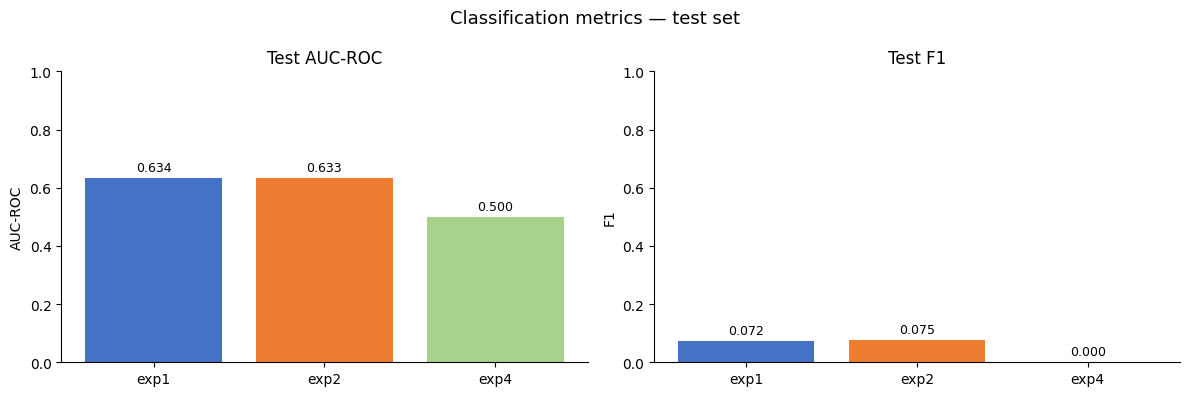

Saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/classification_metrics.png


In [19]:
# ── Step 9b: Full classification metrics table ────────────────────────────────
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import matplotlib.pyplot as plt

print('\n── Classification metrics (test set) ──')
header = f'{"Experiment":<40}  {"AUC-ROC":>8}  {"PR-AUC":>8}  {"Precision":>10}  {"Recall":>8}  {"F1":>8}'
print(header)
print('─' * len(header))

rows_for_plot = []
for key in LOG_ORDER:
    if key not in results:
        continue
    r = results[key]
    p  = r.test_precision if r.test_precision is not None else float('nan')
    rc = r.test_recall    if r.test_recall    is not None else float('nan')
    f1 = r.test_f1        if r.test_f1        is not None else float('nan')
    pa = r.test_pr_auc    if r.test_pr_auc    is not None else float('nan')
    au = r.test_roc_auc   if r.test_roc_auc   is not None else float('nan')
    print(f'{r.experiment_name:<40}  {au:>8.4f}  {pa:>8.4f}  {p:>10.4f}  {rc:>8.4f}  {f1:>8.4f}')
    rows_for_plot.append({'Experiment': r.experiment_name, 'AUC-ROC': au,
                          'PR-AUC': pa, 'Precision': p, 'Recall': rc, 'F1': f1})

# Save as CSV
metrics_df = pd.DataFrame(rows_for_plot)
metrics_path = os.path.join(RESULTS_DIR, 'classification_metrics.csv')
metrics_df.to_csv(metrics_path, index=False)
print(f'\nSaved → {metrics_path}')

# Bar chart — AUC-ROC and F1 side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
exp_labels = [r['Experiment'].split('_')[0] for r in rows_for_plot]
colors     = ['#4472C4','#ED7D31','#A9D18E','#FF0000']

for ax, metric in zip(axes, ['AUC-ROC', 'F1']):
    vals = [r[metric] for r in rows_for_plot]
    bars = ax.bar(exp_labels, vals, color=colors[:len(vals)], edgecolor='none')
    ax.set_ylim(0, 1.0)
    ax.set_title(f'Test {metric}', fontsize=12)
    ax.set_ylabel(metric)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.spines[['top','right']].set_visible(False)

plt.suptitle('Classification metrics — test set', fontsize=13)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'classification_metrics.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

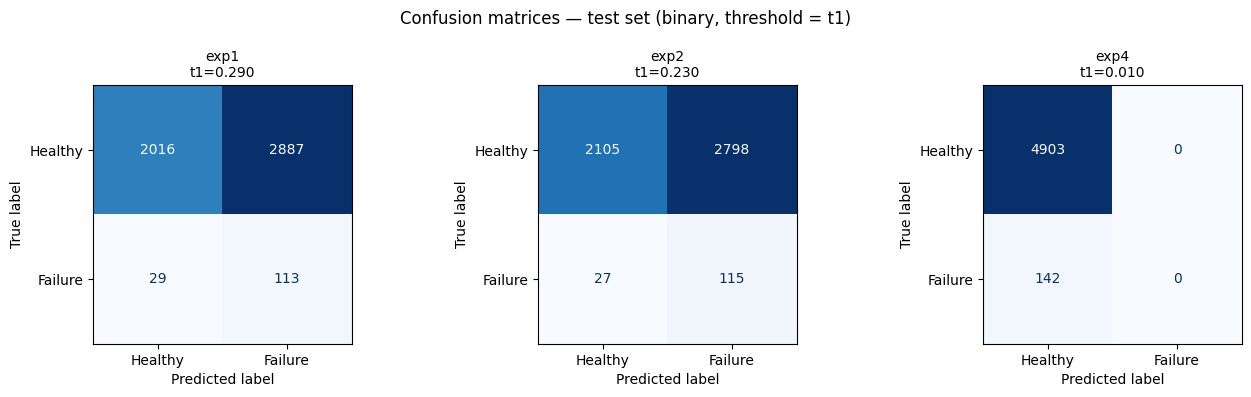

Saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/confusion_matrices.png


In [20]:
# ── Step 9c: Confusion matrices (binary) for each experiment ─────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

n_exps = sum(1 for k in LOG_ORDER if k in results)
fig, axes = plt.subplots(1, n_exps, figsize=(4.5 * n_exps, 4))
if n_exps == 1:
    axes = [axes]

for ax, key in zip(axes, [k for k in LOG_ORDER if k in results]):
    r  = results[key]
    t1 = r.thresholds[0]
    y_pred_bin = (r.test_probs >= t1).astype(int)
    cm_arr = confusion_matrix(y_test_binary, y_pred_bin)
    disp   = ConfusionMatrixDisplay(cm_arr, display_labels=['Healthy','Failure'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    short = r.experiment_name.split('_')[0]
    ax.set_title(f'{short}\nt1={t1:.3f}', fontsize=10)

plt.suptitle('Confusion matrices — test set (binary, threshold = t1)', fontsize=12)
plt.tight_layout()
conf_path = os.path.join(FIGURES_DIR, 'confusion_matrices.png')
plt.savefig(conf_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {conf_path}')

In [21]:
# ── Step 10b: Per-experiment test-set cost breakdown ──────────────────────────

print('\n── Test-set cost breakdown per experiment ──\n')

for key in LOG_ORDER:
    if key not in results:
        continue
    r  = results[key]
    cm_key = CostMatrix(fn_weight=0.5 if 'fn05' in key else 1.0)
    t1, t2, t3, t4 = r.thresholds
    test_pred = np.zeros(len(r.test_probs), dtype=int)
    test_pred[r.test_probs >= t1] = 1
    test_pred[r.test_probs >= t2] = 2
    test_pred[r.test_probs >= t3] = 3
    test_pred[r.test_probs >= t4] = 4

    print(f'{'='*60}')
    print(f'  {r.experiment_name}')
    print(f'  Test cost: {r.test_total_cost:.0f}   AUC: {r.test_roc_auc:.4f}')
    print(f'{'='*60}')
    print(f'  {"Actual":<10} {"Pred":<10} {"N":>6}  {"Unit":>6}  {"Total":>8}  {"Pct":>6}')
    print(f'  {"-"*55}')

    total = r.test_total_cost if r.test_total_cost else 1
    for actual in range(5):
        for pred in range(5):
            mask = (y_test_5class == actual) & (test_pred == pred)
            n    = mask.sum()
            if n == 0:
                continue
            unit  = int(cm_key.matrix[actual][pred])
            cost  = n * unit
            pct   = cost / total * 100 if total > 0 else 0
            flag  = ' ← FN' if actual > pred else (' ← FP' if pred > actual else '')
            print(f'  {actual:<10} {pred:<10} {n:>6}  {unit:>6}  {cost:>8}  {pct:>5.1f}%{flag}')
    print()


── Test-set cost breakdown per experiment ──

  exp1_log_loss
  Test cost: 46393   AUC: 0.6340
  Actual     Pred            N    Unit     Total     Pct
  -------------------------------------------------------
  0          0            2016       0         0    0.0%
  0          1             553       7      3871    8.3% ← FP
  0          2             370       8      2960    6.4% ← FP
  0          3             242       9      2178    4.7% ← FP
  0          4            1722      10     17220   37.1% ← FP
  1          0               5     200      1000    2.2% ← FN
  1          1               1       0         0    0.0%
  1          2               1       7         7    0.0% ← FP
  1          3               2       8        16    0.0% ← FP
  1          4              17       9       153    0.3% ← FP
  2          0               3     300       900    1.9% ← FN
  2          1               4     200       800    1.7% ← FN
  2          3               2       7        14    0.0

In [22]:
# ── Step 10: Cost reduction analysis ─────────────────────────────────────────

print('\n── Cost reduction vs Exp1 baseline ──')

if 'exp1_log_loss' in results:
    baseline_val  = results['exp1_log_loss'].val_total_cost
    baseline_test = results['exp1_log_loss'].test_total_cost

    print(f'Baseline (Exp1) val cost  : {baseline_val:.2f}')
    print(f'Baseline (Exp1) test cost : {baseline_test:.2f}')
    print()

    for key in ['exp2_focal_loss', 'exp3_cost_aware_focal', 'exp4_cost_aware_fn05']:
        if key not in results:
            continue
        r    = results[key]
        dv   = baseline_val  - r.val_total_cost
        dt   = baseline_test - r.test_total_cost
        pv   = dv / baseline_val  * 100
        pt   = dt / baseline_test * 100
        print(f'{r.experiment_name}')
        print(f'  Val  cost: {r.val_total_cost:>10.2f}   change: {dv:>+10.2f}  ({pv:>+6.1f}%)')
        print(f'  Test cost: {r.test_total_cost:>10.2f}   change: {dt:>+10.2f}  ({pt:>+6.1f}%)')
        print()


── Cost reduction vs Exp1 baseline ──
Baseline (Exp1) val cost  : 43472.00
Baseline (Exp1) test cost : 46393.00

exp2_focal_loss
  Val  cost:   43987.00   change:    -515.00  (  -1.2%)
  Test cost:   46345.00   change:     +48.00  (  +0.1%)

exp4_cost_aware_fn05
  Val  cost:   28700.00   change:  +14772.00  ( +34.0%)
  Test cost:   28050.00   change:  +18343.00  ( +39.5%)



In [23]:
# ── Step 11: Sensitivity analysis summary ─────────────────────────────────────

if sensitivity_df is not None:
    print('\n── Sensitivity analysis (fn_weight sweep) ──')
    print(sensitivity_df[
        ['fn_weight', 'alpha', 'val_total_cost', 'test_total_cost',
         'threshold_t1', 'threshold_t4']
    ].to_string(index=False))

    # Highlight the optimal fn_weight
    best_row = sensitivity_df.loc[sensitivity_df['val_total_cost'].idxmin()]
    print(f'\nOptimal fn_weight (lowest val cost): {best_row["fn_weight"]}')
    print(f'  Val cost  : {best_row["val_total_cost"]:.2f}')
    print(f'  Test cost : {best_row["test_total_cost"]:.2f}')

    # Check for alpha saturation
    above_1 = sensitivity_df[sensitivity_df['fn_weight'] >= 1.0]
    cost_range = above_1['val_total_cost'].max() - above_1['val_total_cost'].min()
    print(f'\nAlpha saturation check (fn_weight >= 1.0):')
    print(f'  Cost range above fn_weight=1.0: {cost_range:.2f}')
    if cost_range < 100:
        print('  CONFIRMED: Costs are effectively identical above fn_weight=1.0')
        print('  Alpha saturation is empirically confirmed.')
    else:
        print('  NOTE: Some variation above fn_weight=1.0 — check results carefully')


── Sensitivity analysis (fn_weight sweep) ──
 fn_weight  alpha  val_total_cost  test_total_cost  threshold_t1  threshold_t4
      0.25 0.9115         14350.0          14025.0          0.57          0.63
      0.50 0.9537         28700.0          28050.0          0.01          0.07
      0.75 0.9686         43050.0          42075.0          0.01          0.07
      1.00 0.9763         71626.0          69159.0          0.01          0.51
      1.50 0.9841         66026.0          61513.0          0.01          0.49
      2.00 0.9880         74383.0          66137.0          0.01          0.49
      3.00 0.9920         93642.0          81645.0          0.01          0.49

Optimal fn_weight (lowest val cost): 0.25
  Val cost  : 14350.00
  Test cost : 14025.00

Alpha saturation check (fn_weight >= 1.0):
  Cost range above fn_weight=1.0: 27616.00
  NOTE: Some variation above fn_weight=1.0 — check results carefully


In [24]:
# ── Step 12: Generate all thesis figures ──────────────────────────────────────

print('Generating figures...')

gen = FigureGenerator(tracker, figures_dir=FIGURES_DIR)

try:
    saved = gen.save_all_figures(
        y_val_binary  = y_val_binary,
        y_test_binary = y_test_binary,
        y_test_5class = y_test_5class,
        cost_matrix   = CostMatrix(fn_weight=1.0),
    )
    print(f'\n{len(saved)} figures saved to {FIGURES_DIR}:')
    for name, path in saved.items():
        print(f'  {name:<40} → {os.path.basename(path)}')
except Exception as e:
    print(f'Figure generation error: {e}')
    print('Individual figures may still have been saved — check FIGURES_DIR')

Generating figures...
  [Figures] saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/cost_comparison.png
  [Figures] saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/roc_comparison_test.png
  [Figures] saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/roc_comparison_val.png
  [Figures] saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/confusion_matrices.png
  [Figures] saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/prob_distributions.png
  [Figures] saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/threshold_comparison.png
  [Figures] saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/cost_breakdown

In [25]:
# ── Step 13: Generate plain-text experiment report ────────────────────────────

reporter = ReportGenerator(tracker, output_dir=RESULTS_DIR)
report   = reporter.generate(save=True)
print(report)

  [Report] saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/results/experiment_report.txt
EXPERIMENT REPORT
Thesis: Cost-Aware Learning for Failure Prediction
Generated: 2026-05-02 00:10:15

RESEARCH QUESTIONS
────────────────────────────────────────
RQ1: Does cost-aware training reduce total maintenance cost
     compared to standard loss functions?
RQ2: How does varying failure-class weight affect FN/FP trade-off?
RQ3: How sensitive is performance to class weights?

EXPERIMENT RESULTS
────────────────────────────────────────
Experiment                            Val cost   Test cost      AUC
─────────────────────────────────────────────────────────────────
exp1_log_loss                         43472.00    46393.00   0.6340
exp2_focal_loss                       43987.00    46345.00   0.6327
exp4_cost_aware_fn05                  28700.00    28050.00   0.5000

COST REDUCTION ANALYSIS
────────────────────────────────────────
Baseline (Exp1

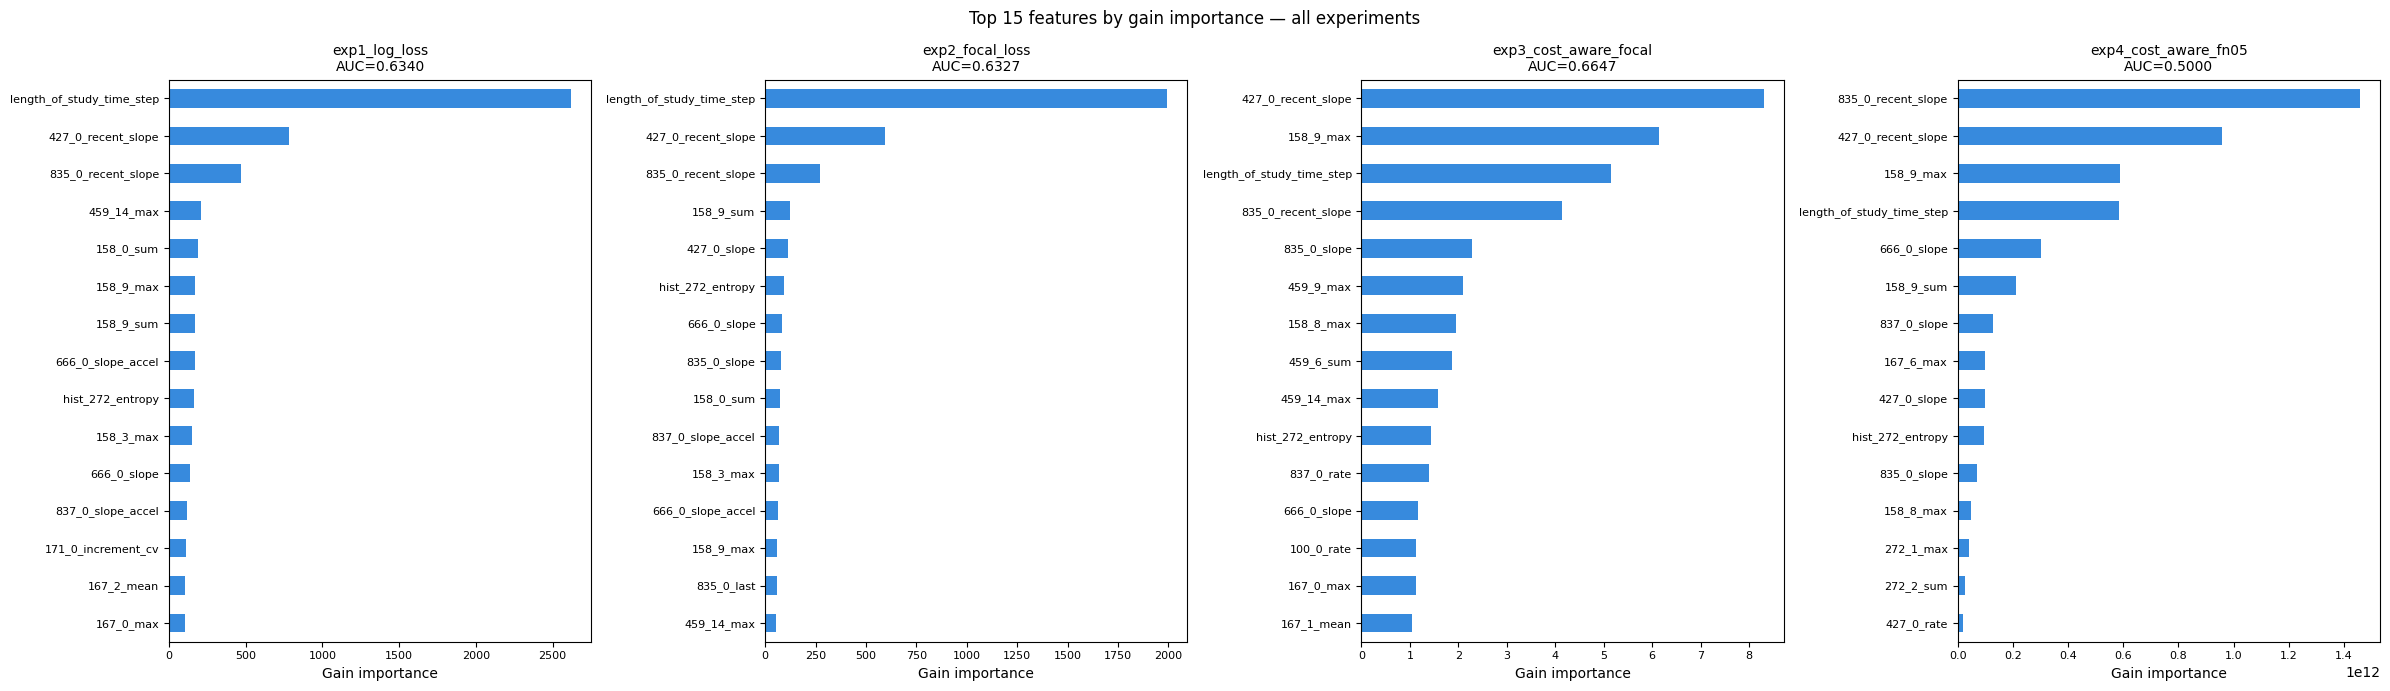

Saved → /content/drive/MyDrive/MasterThesis-2026/predictive-maintanance-SCANIA-componentX/outputs/figures/feature_importance_all.png


In [26]:
# ── Step 14: Feature importance for each experiment ───────────────────────────

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 7))
if len(results) == 1:
    axes = [axes]

for ax, (key, r) in zip(axes, results.items()):
    importance = pd.Series(
        r.model.feature_importance(importance_type='gain'),
        index=r.model.feature_name()
    ).sort_values(ascending=False).head(15)

    importance.sort_values().plot(
        kind='barh', ax=ax, color='#378ADD', edgecolor='none'
    )
    ax.set_title(f'{r.experiment_name}\nAUC={r.test_roc_auc:.4f}', fontsize=10)
    ax.set_xlabel('Gain importance')
    ax.tick_params(labelsize=8)

plt.suptitle('Top 15 features by gain importance — all experiments', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, 'feature_importance_all.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {fig_path}')

In [27]:
# ── Step 15: Final output file checklist ─────────────────────────────────────

print('='*60)
print('  MERGE COMPLETE — output file checklist')
print('='*60)

expected_outputs = [
    (RESULTS_DIR, 'results.csv',               'All experiment metrics'),
    (RESULTS_DIR, 'comparison_table.csv',      'Thesis comparison table'),
    (RESULTS_DIR, 'sensitivity_results.csv',   'fn_weight sweep results'),
    (RESULTS_DIR, 'classification_metrics.csv','Precision/Recall/F1/AUC'),
    (RESULTS_DIR, 'experiment_report.txt',     'Plain-text report'),
    (FIGURES_DIR, 'cost_comparison.png',       'Bar chart — RQ1'),
    (FIGURES_DIR, 'roc_comparison_test.png',   'ROC curves'),
    (FIGURES_DIR, 'sensitivity_curve.png',     'Cost vs fn_weight — RQ3'),
    (FIGURES_DIR, 'threshold_comparison.png',  'Thresholds — RQ2'),
    (FIGURES_DIR, 'classification_metrics.png','AUC-ROC and F1 bars'),
    (FIGURES_DIR, 'confusion_matrices.png',    'Confusion matrices'),
    (FIGURES_DIR, 'feature_importance_all.png','Feature importance'),
]

all_ok = True
for directory, filename, description in expected_outputs:
    full_path = os.path.join(directory, filename)
    exists    = os.path.exists(full_path)
    status    = 'OK    ' if exists else 'MISSING'
    if not exists:
        all_ok = False
    print(f'  [{status}]  {description:<35}  {filename}')

print()
if all_ok:
    print('  All output files present. Ready to write Results chapter.')
else:
    print('  Some files missing — check cells above for errors.')

  MERGE COMPLETE — output file checklist
  [OK    ]  All experiment metrics               results.csv
  [OK    ]  Thesis comparison table              comparison_table.csv
  [OK    ]  fn_weight sweep results              sensitivity_results.csv
  [OK    ]  Precision/Recall/F1/AUC              classification_metrics.csv
  [OK    ]  Plain-text report                    experiment_report.txt
  [OK    ]  Bar chart — RQ1                      cost_comparison.png
  [OK    ]  ROC curves                           roc_comparison_test.png
  [OK    ]  Cost vs fn_weight — RQ3              sensitivity_curve.png
  [OK    ]  Thresholds — RQ2                     threshold_comparison.png
  [OK    ]  AUC-ROC and F1 bars                  classification_metrics.png
  [OK    ]  Confusion matrices                   confusion_matrices.png
  [OK    ]  Feature importance                   feature_importance_all.png

  All output files present. Ready to write Results chapter.
